#  DQN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://en.wikipedia.org/wiki/Q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
* https://github.com/pylSER/Deep-Reinforcement-learning-Mountain-Car/tree/master
* https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/

## Задачи для совместного разбора

1\. Обсудите основные отличия DQN от классических вариантов Q-learning.

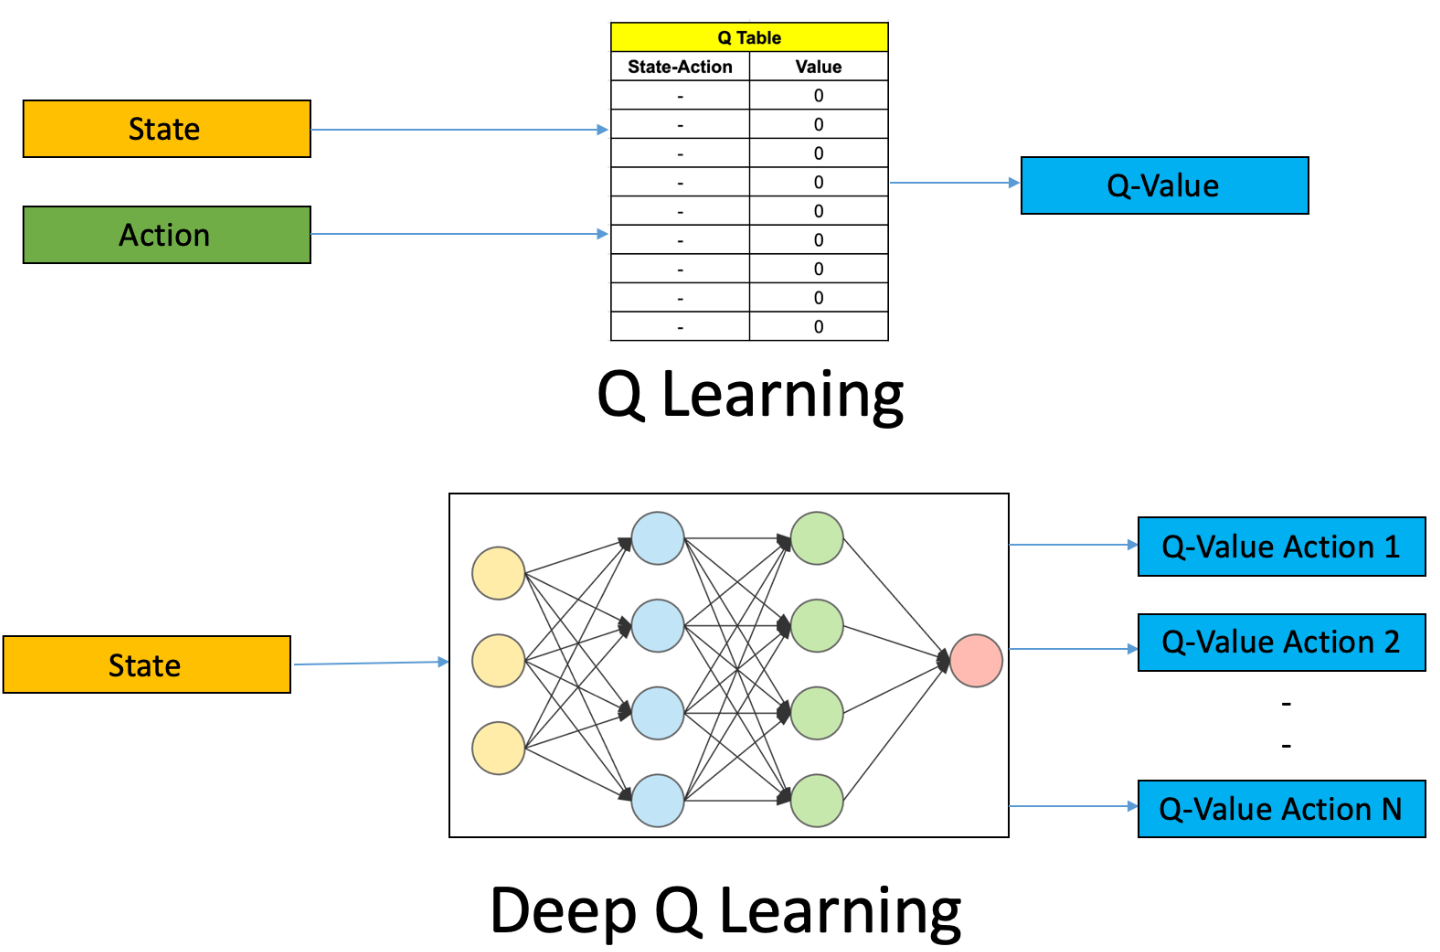

<img src="https://valohai.com/blog/reinforcement-learning-tutorial-part-1-q-learning/image4.png" width="500">
<img src="https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/4.png" width="500">


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите класс `ReplayMemory` для хранения переходов между состояниями.

- [ ] Проверено на семинаре

In [1]:
from collections import namedtuple, deque
import random

Transition = namedtuple(
    'Transition',
    ('state', 'action', 'next_state', 'reward', 'done')
)

class ReplayMemory(object):
    def __init__(self, capacity):
        """capacity - максимальный размер хранилища"""
        if not isinstance(capacity, int) or capacity <= 0:
            raise ValueError("capacity должен быть положительным целым числом")
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        """Сохраняет переход. При нехватке места самые старые записи удаляются."""
        transition = args[0] if len(args) == 1 and isinstance(args[0], Transition) else Transition(*args)
        self.memory.append(transition)

    def sample(self, batch_size):
        """Возвращает batch_size случайно выбранных переходов без повторений."""
        if not isinstance(batch_size, int) or batch_size <= 0:
            raise ValueError("batch_size должен быть положительным целым числом")
        if batch_size > len(self.memory):
            raise ValueError("batch_size не может превышать текущее число переходов")
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [2]:
from collections import namedtuple, deque
import random

Transition = namedtuple(
    'Transition',
    ('state', 'action', 'next_state', 'reward', 'done')
)

class ReplayMemory(object):
    def __init__(self, capacity):
        """capacity - максимальный размер хранилища"""
        if not isinstance(capacity, int) or capacity <= 0:
            raise ValueError("capacity должен быть положительным целым числом")
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        """Сохраняет переход. При нехватке места самые старые записи удаляются."""
        transition = args[0] if len(args) == 1 and isinstance(args[0], Transition) else Transition(*args)
        self.memory.append(transition)

    def sample(self, batch_size):
        """Возвращает batch_size случайно выбранных переходов без повторений."""
        if not isinstance(batch_size, int) or batch_size <= 0:
            raise ValueError("batch_size должен быть положительным целым числом")
        if batch_size > len(self.memory):
            raise ValueError("batch_size не может превышать текущее число переходов")
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [3]:
# Создание хранилища на 10000 переходов
memory = ReplayMemory(10000)

# Добавление перехода
state = [0.1, 0.2, 0.3]
action = 1
next_state = [0.2, 0.3, 0.4]
reward = 1.0
done = False
memory.push(state, action, next_state, reward, done)

# Получение батча для обучения
if len(memory) >= 32:
    batch = memory.sample(32)
    # batch - список из 32 объектов Transition

<p class="task" id="2"></p>

2\. Допишите класс `DQN` для моделирования Q-функции.

- [ ] Проверено на семинаре

In [4]:
import torch
import torch.nn as nn

class DQN(nn.Module):
    """Нейронная сеть для аппроксимации Q-функции."""
    def __init__(self, n_observations, n_actions, hidden_dim=64):
        super().__init__()
        if n_observations <= 0 or n_actions <= 0 or hidden_dim <= 0:
            raise ValueError("Размерности сети должны быть положительными")
        self.n_observations = int(n_observations)
        self.n_actions = int(n_actions)
        self.hidden_dim = int(hidden_dim)
        self.network = nn.Sequential(
            nn.Linear(self.n_observations, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.n_actions),
        )
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов для стабильного начала обучения."""
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        """Для каждого состояния возвращает Q-значение каждого доступного действия."""
        x = torch.as_tensor(x, dtype=torch.float32)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        return self.network(x)

In [5]:
import torch
import torch.nn as nn

class DQN(nn.Module):
    """Нейронная сеть для аппроксимации Q-функции."""
    def __init__(self, n_observations, n_actions, hidden_dim=64):
        super().__init__()
        if n_observations <= 0 or n_actions <= 0 or hidden_dim <= 0:
            raise ValueError("Размерности сети должны быть положительными")
        self.n_observations = int(n_observations)
        self.n_actions = int(n_actions)
        self.hidden_dim = int(hidden_dim)
        self.network = nn.Sequential(
            nn.Linear(self.n_observations, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.n_actions),
        )
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов для стабильного начала обучения."""
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        """Для каждого состояния возвращает Q-значение каждого доступного действия."""
        x = torch.as_tensor(x, dtype=torch.float32)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        return self.network(x)

In [6]:
import torch

# Создание модели
n_observations = 4  # Например, для CartPole
n_actions = 2       # Влево/вправо
model = DQN(n_observations, n_actions)

# Пример прямого прохода
state = torch.randn(1, n_observations)  # Одно состояние
q_values = model(state)  # Размер: (1, n_actions)

states_batch = torch.randn(32, n_observations)  # Батч из 32 состояний
q_values_batch = model(states_batch)  # Размер: (32, n_actions)

print(f"Q-значения для одиночного состояния: {q_values}")
print(f"Форма Q-значений для батча: {q_values_batch.shape}")

Q-значения для одиночного состояния: tensor([[-1.8425,  0.2555]], grad_fn=<AddmmBackward0>)
Форма Q-значений для батча: torch.Size([32, 2])


<p class="task" id="3"></p>

3\. Допишите классы `PolicyConfig` для настроек политики агента и `Policy` для реализации политики.

- [ ] Проверено на семинаре

In [7]:
from dataclasses import dataclass, asdict
from typing import Dict, Any
import torch as th

@dataclass
class PolicyConfig:
    """Настройки ε-жадной DQN-политики."""
    observation_dim: int
    action_dim: int
    hidden_dim: int = 64
    device: str = "cuda" if th.cuda.is_available() else "cpu"
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: float = 0.992
    use_double_dqn: bool = True
    seed: int = 0

    def __post_init__(self):
        if self.observation_dim <= 0 or self.action_dim <= 0 or self.hidden_dim <= 0:
            raise ValueError("Размерности observation_dim, action_dim и hidden_dim должны быть > 0")
        if not (0.0 <= self.epsilon_end <= self.epsilon_start <= 1.0):
            raise ValueError("Должно выполняться 0 <= epsilon_end <= epsilon_start <= 1")
        if not (0.0 < self.epsilon_decay <= 1.0):
            raise ValueError("epsilon_decay должен принадлежать интервалу (0, 1]")

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    @classmethod
    def from_dict(cls, data: Dict[str, Any]):
        return cls(**data)

In [8]:
import os
import random
import numpy as np
import torch as th

class Policy:
    def __init__(self, policy_cfg: PolicyConfig):
        self.cfg = policy_cfg
        self.device = th.device(policy_cfg.device)
        self.epsilon = float(policy_cfg.epsilon_start)
        self.train_mode = True
        self.steps_done = 0
        self._set_seed(policy_cfg.seed)
        self._build_networks()
        self.sync_models()

    def _set_seed(self, seed: int):
        random.seed(seed)
        np.random.seed(seed)
        th.manual_seed(seed)
        if th.cuda.is_available():
            th.cuda.manual_seed_all(seed)

    def _build_networks(self):
        self.policy_network = DQN(
            self.cfg.observation_dim, self.cfg.action_dim, self.cfg.hidden_dim
        ).to(self.device)
        self.target_network = DQN(
            self.cfg.observation_dim, self.cfg.action_dim, self.cfg.hidden_dim
        ).to(self.device)

    def sync_models(self):
        """Копирует веса policy network в target network."""
        self.target_network.load_state_dict(self.policy_network.state_dict())
        self.target_network.eval()

    def get_best_action(self, state: th.Tensor) -> int:
        """Выбирает действие по ε-жадной стратегии; в eval-режиме — жадно."""
        self.steps_done += 1
        if self.train_mode and random.random() < self.epsilon:
            return random.randrange(self.cfg.action_dim)
        state = th.as_tensor(state, dtype=th.float32, device=self.device)
        if state.ndim == 1:
            state = state.unsqueeze(0)
        with th.no_grad():
            return int(self.policy_network(state).argmax(dim=1).item())

    def decay_epsilon(self):
        """Уменьшает ε один раз после эпизода."""
        self.epsilon = max(
            float(self.cfg.epsilon_end),
            self.epsilon * float(self.cfg.epsilon_decay)
        )

    def train(self):
        self.train_mode = True
        self.policy_network.train()

    def eval(self):
        self.train_mode = False
        self.policy_network.eval()

    def save(self, path: str = "policy_checkpoint.pth"):
        """Сохраняет обе сети, конфигурацию и состояние exploration."""
        directory = os.path.dirname(path)
        if directory:
            os.makedirs(directory, exist_ok=True)
        th.save({
            'policy_state_dict': self.policy_network.state_dict(),
            'target_state_dict': self.target_network.state_dict(),
            'epsilon': float(self.epsilon),
            'steps_done': int(self.steps_done),
            'config': self.cfg.to_dict(),
        }, path)

    def load(self, path: str = "policy_checkpoint.pth"):
        """Загружает checkpoint; при необходимости пересоздаёт архитектуру сети."""
        if not os.path.exists(path):
            raise FileNotFoundError(f"Файл {path} не найден")
        try:
            checkpoint = th.load(path, map_location=self.device, weights_only=True)
        except TypeError:  # совместимость со старыми версиями PyTorch
            checkpoint = th.load(path, map_location=self.device)

        cfg_dict = checkpoint.get('config')
        if cfg_dict:
            cfg_dict = dict(cfg_dict)
            cfg_dict['device'] = str(self.device)
            loaded_cfg = PolicyConfig.from_dict(cfg_dict)
            architecture_changed = (
                loaded_cfg.observation_dim != self.cfg.observation_dim or
                loaded_cfg.action_dim != self.cfg.action_dim or
                loaded_cfg.hidden_dim != self.cfg.hidden_dim
            )
            self.cfg = loaded_cfg
            if architecture_changed:
                self._build_networks()

        self.policy_network.load_state_dict(checkpoint['policy_state_dict'])
        self.target_network.load_state_dict(checkpoint.get('target_state_dict', checkpoint['policy_state_dict']))
        self.epsilon = float(checkpoint.get('epsilon', self.cfg.epsilon_start))
        self.steps_done = int(checkpoint.get('steps_done', 0))
        self.target_network.eval()
        return self

In [9]:
from dataclasses import dataclass, asdict
from typing import Dict, Any
import torch as th

@dataclass
class PolicyConfig:
    """Настройки ε-жадной DQN-политики."""
    observation_dim: int
    action_dim: int
    hidden_dim: int = 64
    device: str = "cuda" if th.cuda.is_available() else "cpu"
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: float = 0.992
    use_double_dqn: bool = True
    seed: int = 0

    def __post_init__(self):
        if self.observation_dim <= 0 or self.action_dim <= 0 or self.hidden_dim <= 0:
            raise ValueError("Размерности observation_dim, action_dim и hidden_dim должны быть > 0")
        if not (0.0 <= self.epsilon_end <= self.epsilon_start <= 1.0):
            raise ValueError("Должно выполняться 0 <= epsilon_end <= epsilon_start <= 1")
        if not (0.0 < self.epsilon_decay <= 1.0):
            raise ValueError("epsilon_decay должен принадлежать интервалу (0, 1]")

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    @classmethod
    def from_dict(cls, data: Dict[str, Any]):
        return cls(**data)

import torch
import torch.nn as nn

class DQN(nn.Module):
    """Нейронная сеть для аппроксимации Q-функции."""
    def __init__(self, n_observations, n_actions, hidden_dim=64):
        super().__init__()
        if n_observations <= 0 or n_actions <= 0 or hidden_dim <= 0:
            raise ValueError("Размерности сети должны быть положительными")
        self.n_observations = int(n_observations)
        self.n_actions = int(n_actions)
        self.hidden_dim = int(hidden_dim)
        self.network = nn.Sequential(
            nn.Linear(self.n_observations, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.n_actions),
        )
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов для стабильного начала обучения."""
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        """Для каждого состояния возвращает Q-значение каждого доступного действия."""
        x = torch.as_tensor(x, dtype=torch.float32)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        return self.network(x)

import os
import random
import numpy as np
import torch as th

class Policy:
    def __init__(self, policy_cfg: PolicyConfig):
        self.cfg = policy_cfg
        self.device = th.device(policy_cfg.device)
        self.epsilon = float(policy_cfg.epsilon_start)
        self.train_mode = True
        self.steps_done = 0
        self._set_seed(policy_cfg.seed)
        self._build_networks()
        self.sync_models()

    def _set_seed(self, seed: int):
        random.seed(seed)
        np.random.seed(seed)
        th.manual_seed(seed)
        if th.cuda.is_available():
            th.cuda.manual_seed_all(seed)

    def _build_networks(self):
        self.policy_network = DQN(
            self.cfg.observation_dim, self.cfg.action_dim, self.cfg.hidden_dim
        ).to(self.device)
        self.target_network = DQN(
            self.cfg.observation_dim, self.cfg.action_dim, self.cfg.hidden_dim
        ).to(self.device)

    def sync_models(self):
        """Копирует веса policy network в target network."""
        self.target_network.load_state_dict(self.policy_network.state_dict())
        self.target_network.eval()

    def get_best_action(self, state: th.Tensor) -> int:
        """Выбирает действие по ε-жадной стратегии; в eval-режиме — жадно."""
        self.steps_done += 1
        if self.train_mode and random.random() < self.epsilon:
            return random.randrange(self.cfg.action_dim)
        state = th.as_tensor(state, dtype=th.float32, device=self.device)
        if state.ndim == 1:
            state = state.unsqueeze(0)
        with th.no_grad():
            return int(self.policy_network(state).argmax(dim=1).item())

    def decay_epsilon(self):
        """Уменьшает ε один раз после эпизода."""
        self.epsilon = max(
            float(self.cfg.epsilon_end),
            self.epsilon * float(self.cfg.epsilon_decay)
        )

    def train(self):
        self.train_mode = True
        self.policy_network.train()

    def eval(self):
        self.train_mode = False
        self.policy_network.eval()

    def save(self, path: str = "policy_checkpoint.pth"):
        """Сохраняет обе сети, конфигурацию и состояние exploration."""
        directory = os.path.dirname(path)
        if directory:
            os.makedirs(directory, exist_ok=True)
        th.save({
            'policy_state_dict': self.policy_network.state_dict(),
            'target_state_dict': self.target_network.state_dict(),
            'epsilon': float(self.epsilon),
            'steps_done': int(self.steps_done),
            'config': self.cfg.to_dict(),
        }, path)

    def load(self, path: str = "policy_checkpoint.pth"):
        """Загружает checkpoint; при необходимости пересоздаёт архитектуру сети."""
        if not os.path.exists(path):
            raise FileNotFoundError(f"Файл {path} не найден")
        try:
            checkpoint = th.load(path, map_location=self.device, weights_only=True)
        except TypeError:  # совместимость со старыми версиями PyTorch
            checkpoint = th.load(path, map_location=self.device)

        cfg_dict = checkpoint.get('config')
        if cfg_dict:
            cfg_dict = dict(cfg_dict)
            cfg_dict['device'] = str(self.device)
            loaded_cfg = PolicyConfig.from_dict(cfg_dict)
            architecture_changed = (
                loaded_cfg.observation_dim != self.cfg.observation_dim or
                loaded_cfg.action_dim != self.cfg.action_dim or
                loaded_cfg.hidden_dim != self.cfg.hidden_dim
            )
            self.cfg = loaded_cfg
            if architecture_changed:
                self._build_networks()

        self.policy_network.load_state_dict(checkpoint['policy_state_dict'])
        self.target_network.load_state_dict(checkpoint.get('target_state_dict', checkpoint['policy_state_dict']))
        self.epsilon = float(checkpoint.get('epsilon', self.cfg.epsilon_start))
        self.steps_done = int(checkpoint.get('steps_done', 0))
        self.target_network.eval()
        return self

In [10]:
# Создание конфигурации и политики
policy_config = PolicyConfig(
    observation_dim=4,
    action_dim=2,
    hidden_dim=64,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.992,
    use_double_dqn=True,
    seed=0,
)
policy = Policy(policy_config)
print(policy.policy_network)
print(f"Устройство: {policy.device}; epsilon: {policy.epsilon:.3f}")

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Устройство: cuda; epsilon: 1.000


<p class="task" id="4"></p>

4\. Напишите функцию `plot_metrics`, которая будет использоваться для визуализации процесса обучения: суммарной награды за каждый эпизод и максимальное значение x-координаты машины за эпизод. Для реализации можете воспользоваться `wandb` или любым другим удобным инструментом.

- [ ] Проверено на семинаре

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Optional, Tuple
import pandas as pd
import os
try:
    import wandb
except ImportError:
    wandb = None

def plot_metrics(
    episode_rewards: List[float],
    max_x_positions: List[float],
    episode_lengths: Optional[List[int]] = None,
    epsilon_values: Optional[List[float]] = None,
    losses: Optional[List[float]] = None,
    q_values: Optional[List[float]] = None,
    smoothing_window: int = 10,
    use_wandb: bool = False,
    save_path: Optional[str] = None,
    show_plots: bool = True,
    title_prefix: str = "",
    wandb_config: Optional[Dict] = None
) -> None:
    """
    Визуализирует метрики обучения DQN агента.

    Args:
        episode_rewards: Список суммарных наград за каждый эпизод
        max_x_positions: Список максимальных x-координат за каждый эпизод
        episode_lengths: Список длин эпизодов (опционально)
        epsilon_values: Список значений epsilon за эпизоды (опционально)
        losses: Список значений функции потерь (опционально)
        q_values: Список средних Q-значений (опционально)
        smoothing_window: Размер окна для скользящего среднего
        use_wandb: Использовать ли Weights & Biases для логирования
        save_path: Путь для сохранения графиков
        show_plots: Показывать ли графики на экране
        title_prefix: Префикс для заголовков графиков
        wandb_config: Конфигурация для wandb (опционально)
    """

    if not episode_rewards or not max_x_positions:
        raise ValueError("episode_rewards и max_x_positions не должны быть пустыми")
    if len(episode_rewards) != len(max_x_positions):
        raise ValueError("episode_rewards и max_x_positions должны иметь одинаковую длину")

    episodes = list(range(1, len(episode_rewards) + 1))

    # Создание фигуры с несколькими subplots
    num_plots = 2  # Основные графики: награды и x-координаты
    if episode_lengths:
        num_plots += 1
    if epsilon_values:
        num_plots += 1
    if losses:
        num_plots += 1
    if q_values:
        num_plots += 1

    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 4 * num_plots))
    if num_plots == 1:
        axes = [axes]

    plot_idx = 0

    # 1. График суммарных наград
    ax = axes[plot_idx]
    plot_idx += 1

    # Оригинальные значения
    ax.plot(episodes, episode_rewards, 'b-', alpha=0.3, label='Оригинальные', linewidth=1)

    # Скользящее среднее
    if len(episode_rewards) >= smoothing_window:
        rewards_smooth = pd.Series(episode_rewards).rolling(
            smoothing_window, min_periods=1
        ).mean().values
        ax.plot(episodes, rewards_smooth, 'r-', label=f'Скользящее среднее (окно={smoothing_window})', linewidth=2)

    ax.set_xlabel('Эпизод')
    ax.set_ylabel('Суммарная награда')
    ax.set_title(f'{title_prefix}Суммарная награда за эпизод')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Добавление лучшиих показателей
    best_reward = np.max(episode_rewards)
    avg_reward_last_100 = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
    ax.text(0.02, 0.98, f'Лучшая: {best_reward:.2f}\nСредняя (посл. 100): {avg_reward_last_100:.2f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 2. График максимальных x-координат
    ax = axes[plot_idx]
    plot_idx += 1

    # Оригинальные значения
    ax.plot(episodes, max_x_positions, 'g-', alpha=0.3, label='Оригинальные', linewidth=1)

    # Скользящее среднее
    if len(max_x_positions) >= smoothing_window:
        x_smooth = pd.Series(max_x_positions).rolling(
            smoothing_window, min_periods=1
        ).mean().values
        ax.plot(episodes, x_smooth, 'm-', label=f'Скользящее среднее (окно={smoothing_window})', linewidth=2)

    ax.set_xlabel('Эпизод')
    ax.set_ylabel('Макс. x-координата')
    ax.set_title(f'{title_prefix}Максимальная x-координата за эпизод')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Добавление лучших показателей
    best_x = np.max(max_x_positions)
    avg_x_last_100 = np.mean(max_x_positions[-100:]) if len(max_x_positions) >= 100 else np.mean(max_x_positions)
    ax.text(0.02, 0.98, f'Лучшая: {best_x:.2f}\nСредняя (посл. 100): {avg_x_last_100:.2f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 3. График длин эпизодов 
    if episode_lengths:
        ax = axes[plot_idx]
        plot_idx += 1

        ax.plot(episodes, episode_lengths, 'c-', alpha=0.3, label='Оригинальные', linewidth=1)

        if len(episode_lengths) >= smoothing_window:
            lengths_smooth = pd.Series(episode_lengths).rolling(
                smoothing_window, min_periods=1
            ).mean().values
            ax.plot(episodes, lengths_smooth, 'b-', label=f'Скользящее среднее (окно={smoothing_window})', linewidth=2)

        ax.set_xlabel('Эпизод')
        ax.set_ylabel('Длина эпизода')
        ax.set_title(f'{title_prefix}Длина эпизода')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 4. График epsilon 
    if epsilon_values:
        ax = axes[plot_idx]
        plot_idx += 1

        ax.plot(episodes, epsilon_values, 'orange', linewidth=2)
        ax.set_xlabel('Эпизод')
        ax.set_ylabel('Epsilon')
        ax.set_title(f'{title_prefix}Значение epsilon')
        ax.grid(True, alpha=0.3)

        # Добавляем текущее значение
        current_epsilon = epsilon_values[-1] if epsilon_values else 0
        ax.text(0.02, 0.98, f'Текущее: {current_epsilon:.4f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 5. График потерь
    if losses is not None and len(losses) > 0:
        ax = axes[plot_idx]
        plot_idx += 1

        loss_episodes = list(range(1, len(losses) + 1))
        ax.plot(loss_episodes, losses, 'r-', alpha=0.5, linewidth=1)

        if len(losses) >= smoothing_window:
            losses_smooth = pd.Series(losses).rolling(
                smoothing_window, min_periods=1
            ).mean().values
            ax.plot(loss_episodes, losses_smooth, 'r-', linewidth=2, label='Скользящее среднее')
            ax.legend()

        ax.set_xlabel('Шаг обучения')
        ax.set_ylabel('Потери')
        ax.set_title(f'{title_prefix}Функция потерь')
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')  # Потери лучше смотреть в логарифмической шкале

    # 6. График Q-значений 
    if q_values is not None and len(q_values) > 0:
        ax = axes[plot_idx]

        q_episodes = list(range(1, len(q_values) + 1))
        ax.plot(q_episodes, q_values, 'purple', alpha=0.5, linewidth=1)

        if len(q_values) >= smoothing_window:
            q_smooth = pd.Series(q_values).rolling(
                smoothing_window, min_periods=1
            ).mean().values
            ax.plot(q_episodes, q_smooth, 'purple', linewidth=2, label='Скользящее среднее')
            ax.legend()

        ax.set_xlabel('Шаг обучения')
        ax.set_ylabel('Среднее Q-значение')
        ax.set_title(f'{title_prefix}Средние Q-значения')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Сохранение графиков при указании пути
    if save_path:
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Графики сохранены в {save_path}")

    # Показ графиков
    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    # Логарифмирование в Weights & Biases
    if use_wandb:
        log_to_wandb(
            episode_rewards,
            max_x_positions,
            episode_lengths,
            epsilon_values,
            losses,
            q_values,
            smoothing_window,
            wandb_config
        )

def log_to_wandb(
    episode_rewards: List[float],
    max_x_positions: List[float],
    episode_lengths: Optional[List[int]] = None,
    epsilon_values: Optional[List[float]] = None,
    losses: Optional[List[float]] = None,
    q_values: Optional[List[float]] = None,
    smoothing_window: int = 10,
    config: Optional[Dict] = None
) -> None:
    """Логирует метрики в Weights & Biases"""

    if wandb is None:
        raise ImportError("Для use_wandb=True установите пакет wandb")

    if not wandb.run:
        # Инициализация нового run если нет активного
        if config is None:
            config = {}
        wandb.init(project="dqn-training", config=config)

    # Логирование метрик за последний эпизод
    if episode_rewards:
        wandb.log({
            "episode_reward": episode_rewards[-1],
            "max_x_position": max_x_positions[-1],
            "episode": len(episode_rewards),
        })

    # Логирование скользящего среднего
    if len(episode_rewards) >= smoothing_window:
        avg_reward = np.mean(episode_rewards[-smoothing_window:])
        avg_x = np.mean(max_x_positions[-smoothing_window:])
        wandb.log({
            f"avg_reward_last_{smoothing_window}": avg_reward,
            f"avg_max_x_last_{smoothing_window}": avg_x,
        })

    # Дополнительные метрики
    if episode_lengths:
        wandb.log({"episode_length": episode_lengths[-1]})

    if epsilon_values:
        wandb.log({"epsilon": epsilon_values[-1]})

    if losses and len(losses) > 0:
        avg_loss = np.mean(losses[-100:]) if len(losses) >= 100 else np.mean(losses)
        wandb.log({"avg_loss": avg_loss})

    if q_values and len(q_values) > 0:
        avg_q = np.mean(q_values[-100:]) if len(q_values) >= 100 else np.mean(q_values)
        wandb.log({"avg_q_value": avg_q})

def plot_training_summary(
    metrics_history: Dict[str, List],
    save_dir: str = "plots",
    experiment_name: str = "dqn_experiment"
) -> None:
    """
    Создает полный отчет по обучению со всеми метриками.

    Args:
        metrics_history: Словарь с историей метрик
        save_dir: Директория для сохранения графиков
        experiment_name: Имя эксперимента для имен файлов
    """
    os.makedirs(save_dir, exist_ok=True)

    # Основные графики
    plot_metrics(
        episode_rewards=metrics_history.get('rewards', []),
        max_x_positions=metrics_history.get('max_x', []),
        episode_lengths=metrics_history.get('lengths', []),
        epsilon_values=metrics_history.get('epsilons', []),
        losses=metrics_history.get('losses', []),
        q_values=metrics_history.get('q_values', []),
        show_plots=False,
        save_path=os.path.join(save_dir, f"{experiment_name}_training_metrics.png"),
        title_prefix=f"{experiment_name}: "
    )

    # Дополнительный анализ: гистограмма наград
    if 'rewards' in metrics_history and len(metrics_history['rewards']) > 0:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Гистограмма всех наград
        rewards = metrics_history['rewards']
        ax[0].hist(rewards, bins=50, alpha=0.7, edgecolor='black')
        ax[0].axvline(np.mean(rewards), color='r', linestyle='--', label=f'Среднее: {np.mean(rewards):.2f}')
        ax[0].axvline(np.max(rewards), color='g', linestyle='--', label=f'Максимум: {np.max(rewards):.2f}')
        ax[0].set_xlabel('Суммарная награда')
        ax[0].set_ylabel('Частота')
        ax[0].set_title('Распределение наград за все эпизоды')
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)

        # Награды по третям обучения
        third = len(rewards) // 3
        if third > 0:
            rewards_first = rewards[:third]
            rewards_mid = rewards[third:2*third] if len(rewards) >= 2*third else rewards[third:]
            rewards_last = rewards[2*third:] if len(rewards) >= 3*third else []

            ax[1].boxplot([rewards_first, rewards_mid, rewards_last],
                         tick_labels=['Первая треть', 'Вторая треть', 'Последняя треть'])
            ax[1].set_ylabel('Суммарная награда')
            ax[1].set_title('Эволюция наград по третям обучения')
            ax[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{experiment_name}_rewards_analysis.png"), dpi=150)
        plt.close()

# Пример использования функции
def example_usage():
    """Пример использования plot_metrics"""

    # Генерация тестовых данных
    num_episodes = 500
    episode_rewards = []
    max_x_positions = []
    episode_lengths = []
    epsilon_values = []

    for i in range(num_episodes):
        # Симуляция улучшения производительности
        base_reward = 100 + i * 0.5
        noise = np.random.normal(0, 20)
        episode_rewards.append(max(0, base_reward + noise))

        base_x = 0.5 + i * 0.002
        noise_x = np.random.normal(0, 0.1)
        max_x_positions.append(max(0.1, base_x + noise_x))

        episode_lengths.append(200 + np.random.randint(-50, 50))

        # Epsilon decay
        epsilon_values.append(max(0.01, 1.0 * (0.995 ** i)))

    # Тестовые потери и Q-значения
    num_updates = 1000
    losses = [np.random.exponential(0.1) * (0.99 ** i) for i in range(num_updates)]
    q_values = [10 + np.random.normal(0, 2) + i * 0.01 for i in range(num_updates)]

    # Простая визуализация
    print("Вариант 1: Простая визуализация с matplotlib")
    plot_metrics(
        episode_rewards=episode_rewards,
        max_x_positions=max_x_positions,
        episode_lengths=episode_lengths,
        epsilon_values=epsilon_values,
        losses=losses,
        q_values=q_values,
        smoothing_window=20,
        save_path="training_metrics.png",
        title_prefix="DQN MountainCar: "
    )

    # Создание полного отчета
    print("\nВариант 2: Полный отчет")
    metrics_history = {
        'rewards': episode_rewards,
        'max_x': max_x_positions,
        'lengths': episode_lengths,
        'epsilons': epsilon_values,
        'losses': losses,
        'q_values': q_values,
    }

    plot_training_summary(
        metrics_history=metrics_history,
        save_dir="training_plots",
        experiment_name="mountaincar_dqn"
    )

<p class="task" id="5"></p>

5\. Допишите классы `TrainConfig` для настроек обучения и `Trainer` для реализации процесса обучения.

- [ ] Проверено на семинаре

In [12]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    """Настройки процесса обучения DQN."""
    num_episodes: int = 350
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 64
    target_update_freq: int = 1000      # в шагах среды
    replay_memory_size: int = 50000
    min_memory_size: int = 1000
    max_steps_per_episode: int = 200
    grad_clip: float = 5.0
    train_freq: int = 4                 # один gradient update каждые N шагов
    eval_freq: int = 25
    eval_episodes: int = 5
    print_freq: int = 25
    save_freq: int = 100
    save_dir: str = "checkpoints"
    reward_shaping: bool = False
    velocity_reward_scale: float = 0.0
    goal_bonus: float = 0.0
    seed: int = 0

    def __post_init__(self):
        if self.num_episodes <= 0 or self.batch_size <= 0 or self.replay_memory_size <= 0:
            raise ValueError("Количество эпизодов, batch_size и replay_memory_size должны быть > 0")
        if self.min_memory_size < self.batch_size:
            raise ValueError("min_memory_size должен быть не меньше batch_size")
        if self.min_memory_size > self.replay_memory_size:
            raise ValueError("min_memory_size не может превышать replay_memory_size")
        if not (0.0 <= self.gamma <= 1.0):
            raise ValueError("gamma должен принадлежать [0, 1]")
        if self.train_freq <= 0 or self.target_update_freq <= 0:
            raise ValueError("train_freq и target_update_freq должны быть > 0")

In [13]:
import os
import json
import numpy as np
import torch as th
import torch.nn as nn
import torch.optim as optim

class Trainer:
    def __init__(self, env, train_config: TrainConfig, policy: Policy):
        self.env = env
        self.config = train_config
        self.policy = policy
        self.criterion = nn.SmoothL1Loss()
        self.optimizer = optim.Adam(
            self.policy.policy_network.parameters(), lr=self.config.learning_rate
        )
        self.memory = ReplayMemory(self.config.replay_memory_size)
        self.episode_rewards = []       # исходная награда среды, без shaping
        self.episode_lengths = []
        self.max_x_positions = []
        self.epsilon_values = []
        self.losses = []
        self.q_values = []
        self.eval_history = []
        self.global_step = 0
        self.best_max_x = -float('inf')
        self.best_eval_score = (-1.0, -float('inf'))  # (success_rate, avg_reward)
        os.makedirs(self.config.save_dir, exist_ok=True)

    @staticmethod
    def _to_tensor(state, device):
        if th.is_tensor(state):
            return state.to(device=device, dtype=th.float32)
        return th.as_tensor(state, dtype=th.float32, device=device)

    @staticmethod
    def _position(state) -> float:
        if th.is_tensor(state):
            return float(state[0].detach().cpu().item())
        return float(state[0])

    def _training_reward(self, env_reward, next_state, terminated):
        """Возвращает reward для оптимизации; метрики сохраняют оригинальный env_reward."""
        reward = float(env_reward)
        if self.config.reward_shaping:
            velocity = float(next_state[1].detach().cpu().item()) if th.is_tensor(next_state) else float(next_state[1])
            reward += self.config.velocity_reward_scale * abs(velocity)
            if terminated:
                reward += self.config.goal_bonus
        return reward

    def train(self):
        """Полный цикл обучения DQN."""
        self.policy.train()
        for episode in range(1, self.config.num_episodes + 1):
            state, _ = self.env.reset(seed=self.config.seed + episode - 1)
            state = self._to_tensor(state, self.policy.device)
            reward, length, max_x = self.run_episode(state)

            self.episode_rewards.append(float(reward))
            self.episode_lengths.append(int(length))
            self.max_x_positions.append(float(max_x))
            self.policy.decay_epsilon()
            self.epsilon_values.append(float(self.policy.epsilon))
            self.best_max_x = max(self.best_max_x, float(max_x))

            if episode % self.config.eval_freq == 0 or episode == self.config.num_episodes:
                avg_reward, avg_max_x, success_rate = self.evaluate(
                    self.config.eval_episodes,
                    seed_offset=100000 + episode * self.config.eval_episodes
                )
                self.eval_history.append({
                    'episode': episode,
                    'avg_reward': avg_reward,
                    'avg_max_x': avg_max_x,
                    'success_rate': success_rate,
                })
                score = (success_rate, avg_reward)
                if score > self.best_eval_score:
                    self.best_eval_score = score
                    self.policy.save(os.path.join(self.config.save_dir, 'best_model.pth'))

            if episode % self.config.save_freq == 0:
                self.policy.save(os.path.join(self.config.save_dir, f'checkpoint_{episode}.pth'))

            if episode % self.config.print_freq == 0 or episode == 1:
                recent = self.episode_rewards[-min(20, len(self.episode_rewards)):]
                print(
                    f"Эпизод {episode:4d} | reward={reward:7.1f} | "
                    f"mean20={np.mean(recent):7.1f} | max_x={max_x:6.3f} | "
                    f"epsilon={self.policy.epsilon:.3f} | memory={len(self.memory)}"
                )

        self.policy.save(os.path.join(self.config.save_dir, 'final_model.pth'))
        self.save_history()
        return self

    def run_episode(self, start_state):
        state = start_state
        total_env_reward = 0.0
        max_x = self._position(state)
        episode_length = 0

        for _ in range(self.config.max_steps_per_episode):
            action = self.policy.get_best_action(state)
            next_state, env_reward, terminated, truncated, _ = self.env.step(action)
            episode_done = bool(terminated or truncated)
            next_state_tensor = self._to_tensor(next_state, self.policy.device)
            max_x = max(max_x, self._position(next_state_tensor))

            train_reward = self._training_reward(env_reward, next_state_tensor, terminated)
            self.memory.push(
                state.detach().cpu().clone(),
                int(action),
                next_state_tensor.detach().cpu().clone(),
                float(train_reward),
                bool(terminated),  # bootstrap отключаем только на настоящем terminal
            )

            self.global_step += 1
            if (
                len(self.memory) >= self.config.min_memory_size and
                self.global_step % self.config.train_freq == 0
            ):
                loss, avg_q = self.generate_batch_and_fit()
                self.losses.append(loss)
                self.q_values.append(avg_q)

            if self.global_step % self.config.target_update_freq == 0:
                self.policy.sync_models()

            total_env_reward += float(env_reward)
            episode_length += 1
            state = next_state_tensor
            if episode_done:
                break

        return total_env_reward, episode_length, max_x

    def generate_batch_and_fit(self):
        transitions = self.memory.sample(self.config.batch_size)
        states = th.stack([t.state for t in transitions]).to(self.policy.device)
        actions = th.tensor([t.action for t in transitions], dtype=th.long, device=self.policy.device)
        next_states = th.stack([t.next_state for t in transitions]).to(self.policy.device)
        rewards = th.tensor([t.reward for t in transitions], dtype=th.float32, device=self.policy.device)
        terminals = th.tensor([t.done for t in transitions], dtype=th.float32, device=self.policy.device)

        current_q = self.policy.policy_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with th.no_grad():
            if self.policy.cfg.use_double_dqn:
                next_actions = self.policy.policy_network(next_states).argmax(dim=1)
                next_q = self.policy.target_network(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)
            else:
                next_q = self.policy.target_network(next_states).max(dim=1).values
            target_q = rewards + (1.0 - terminals) * self.config.gamma * next_q

        loss = self.fit_policy_network(current_q, target_q)
        return loss, float(current_q.detach().mean().item())

    def fit_policy_network(self, current_q, target_q):
        self.optimizer.zero_grad(set_to_none=True)
        loss = self.criterion(current_q, target_q)
        loss.backward()
        if self.config.grad_clip > 0:
            th.nn.utils.clip_grad_norm_(
                self.policy.policy_network.parameters(), self.config.grad_clip
            )
        self.optimizer.step()
        return float(loss.item())

    def evaluate(self, episodes=None, seed_offset=200000):
        """Greedy-оценка; возвращает avg_reward, avg_max_x и долю успешных эпизодов."""
        episodes = int(episodes or self.config.eval_episodes)
        was_training = self.policy.train_mode
        self.policy.eval()
        rewards, max_positions = [], []
        successes = 0

        for i in range(episodes):
            state, _ = self.env.reset(seed=self.config.seed + seed_offset + i)
            state = self._to_tensor(state, self.policy.device)
            total_reward = 0.0
            max_x = self._position(state)
            terminated = False
            for _ in range(self.config.max_steps_per_episode):
                action = self.policy.get_best_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                state = self._to_tensor(next_state, self.policy.device)
                total_reward += float(reward)
                max_x = max(max_x, self._position(state))
                if terminated or truncated:
                    break
            rewards.append(total_reward)
            max_positions.append(max_x)
            successes += int(bool(terminated))

        if was_training:
            self.policy.train()
        return (
            float(np.mean(rewards)),
            float(np.mean(max_positions)),
            float(successes / episodes),
        )

    def save_history(self):
        history = {
            'episode_rewards': self.episode_rewards,
            'episode_lengths': self.episode_lengths,
            'max_x_positions': self.max_x_positions,
            'epsilon_values': self.epsilon_values,
            'losses': self.losses,
            'q_values': self.q_values,
            'eval_history': self.eval_history,
        }
        with open(os.path.join(self.config.save_dir, 'training_history.json'), 'w', encoding='utf-8') as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        return history

In [14]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    """Настройки процесса обучения DQN."""
    num_episodes: int = 350
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 64
    target_update_freq: int = 1000      # в шагах среды
    replay_memory_size: int = 50000
    min_memory_size: int = 1000
    max_steps_per_episode: int = 200
    grad_clip: float = 5.0
    train_freq: int = 4                 # один gradient update каждые N шагов
    eval_freq: int = 25
    eval_episodes: int = 5
    print_freq: int = 25
    save_freq: int = 100
    save_dir: str = "checkpoints"
    reward_shaping: bool = False
    velocity_reward_scale: float = 0.0
    goal_bonus: float = 0.0
    seed: int = 0

    def __post_init__(self):
        if self.num_episodes <= 0 or self.batch_size <= 0 or self.replay_memory_size <= 0:
            raise ValueError("Количество эпизодов, batch_size и replay_memory_size должны быть > 0")
        if self.min_memory_size < self.batch_size:
            raise ValueError("min_memory_size должен быть не меньше batch_size")
        if self.min_memory_size > self.replay_memory_size:
            raise ValueError("min_memory_size не может превышать replay_memory_size")
        if not (0.0 <= self.gamma <= 1.0):
            raise ValueError("gamma должен принадлежать [0, 1]")
        if self.train_freq <= 0 or self.target_update_freq <= 0:
            raise ValueError("train_freq и target_update_freq должны быть > 0")

import os
import json
import numpy as np
import torch as th
import torch.nn as nn
import torch.optim as optim

class Trainer:
    def __init__(self, env, train_config: TrainConfig, policy: Policy):
        self.env = env
        self.config = train_config
        self.policy = policy
        self.criterion = nn.SmoothL1Loss()
        self.optimizer = optim.Adam(
            self.policy.policy_network.parameters(), lr=self.config.learning_rate
        )
        self.memory = ReplayMemory(self.config.replay_memory_size)
        self.episode_rewards = []       # исходная награда среды, без shaping
        self.episode_lengths = []
        self.max_x_positions = []
        self.epsilon_values = []
        self.losses = []
        self.q_values = []
        self.eval_history = []
        self.global_step = 0
        self.best_max_x = -float('inf')
        self.best_eval_score = (-1.0, -float('inf'))  # (success_rate, avg_reward)
        os.makedirs(self.config.save_dir, exist_ok=True)

    @staticmethod
    def _to_tensor(state, device):
        if th.is_tensor(state):
            return state.to(device=device, dtype=th.float32)
        return th.as_tensor(state, dtype=th.float32, device=device)

    @staticmethod
    def _position(state) -> float:
        if th.is_tensor(state):
            return float(state[0].detach().cpu().item())
        return float(state[0])

    def _training_reward(self, env_reward, next_state, terminated):
        """Возвращает reward для оптимизации; метрики сохраняют оригинальный env_reward."""
        reward = float(env_reward)
        if self.config.reward_shaping:
            velocity = float(next_state[1].detach().cpu().item()) if th.is_tensor(next_state) else float(next_state[1])
            reward += self.config.velocity_reward_scale * abs(velocity)
            if terminated:
                reward += self.config.goal_bonus
        return reward

    def train(self):
        """Полный цикл обучения DQN."""
        self.policy.train()
        for episode in range(1, self.config.num_episodes + 1):
            state, _ = self.env.reset(seed=self.config.seed + episode - 1)
            state = self._to_tensor(state, self.policy.device)
            reward, length, max_x = self.run_episode(state)

            self.episode_rewards.append(float(reward))
            self.episode_lengths.append(int(length))
            self.max_x_positions.append(float(max_x))
            self.policy.decay_epsilon()
            self.epsilon_values.append(float(self.policy.epsilon))
            self.best_max_x = max(self.best_max_x, float(max_x))

            if episode % self.config.eval_freq == 0 or episode == self.config.num_episodes:
                avg_reward, avg_max_x, success_rate = self.evaluate(
                    self.config.eval_episodes,
                    seed_offset=100000 + episode * self.config.eval_episodes
                )
                self.eval_history.append({
                    'episode': episode,
                    'avg_reward': avg_reward,
                    'avg_max_x': avg_max_x,
                    'success_rate': success_rate,
                })
                score = (success_rate, avg_reward)
                if score > self.best_eval_score:
                    self.best_eval_score = score
                    self.policy.save(os.path.join(self.config.save_dir, 'best_model.pth'))

            if episode % self.config.save_freq == 0:
                self.policy.save(os.path.join(self.config.save_dir, f'checkpoint_{episode}.pth'))

            if episode % self.config.print_freq == 0 or episode == 1:
                recent = self.episode_rewards[-min(20, len(self.episode_rewards)):]
                print(
                    f"Эпизод {episode:4d} | reward={reward:7.1f} | "
                    f"mean20={np.mean(recent):7.1f} | max_x={max_x:6.3f} | "
                    f"epsilon={self.policy.epsilon:.3f} | memory={len(self.memory)}"
                )

        self.policy.save(os.path.join(self.config.save_dir, 'final_model.pth'))
        self.save_history()
        return self

    def run_episode(self, start_state):
        state = start_state
        total_env_reward = 0.0
        max_x = self._position(state)
        episode_length = 0

        for _ in range(self.config.max_steps_per_episode):
            action = self.policy.get_best_action(state)
            next_state, env_reward, terminated, truncated, _ = self.env.step(action)
            episode_done = bool(terminated or truncated)
            next_state_tensor = self._to_tensor(next_state, self.policy.device)
            max_x = max(max_x, self._position(next_state_tensor))

            train_reward = self._training_reward(env_reward, next_state_tensor, terminated)
            self.memory.push(
                state.detach().cpu().clone(),
                int(action),
                next_state_tensor.detach().cpu().clone(),
                float(train_reward),
                bool(terminated),  # bootstrap отключаем только на настоящем terminal
            )

            self.global_step += 1
            if (
                len(self.memory) >= self.config.min_memory_size and
                self.global_step % self.config.train_freq == 0
            ):
                loss, avg_q = self.generate_batch_and_fit()
                self.losses.append(loss)
                self.q_values.append(avg_q)

            if self.global_step % self.config.target_update_freq == 0:
                self.policy.sync_models()

            total_env_reward += float(env_reward)
            episode_length += 1
            state = next_state_tensor
            if episode_done:
                break

        return total_env_reward, episode_length, max_x

    def generate_batch_and_fit(self):
        transitions = self.memory.sample(self.config.batch_size)
        states = th.stack([t.state for t in transitions]).to(self.policy.device)
        actions = th.tensor([t.action for t in transitions], dtype=th.long, device=self.policy.device)
        next_states = th.stack([t.next_state for t in transitions]).to(self.policy.device)
        rewards = th.tensor([t.reward for t in transitions], dtype=th.float32, device=self.policy.device)
        terminals = th.tensor([t.done for t in transitions], dtype=th.float32, device=self.policy.device)

        current_q = self.policy.policy_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with th.no_grad():
            if self.policy.cfg.use_double_dqn:
                next_actions = self.policy.policy_network(next_states).argmax(dim=1)
                next_q = self.policy.target_network(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)
            else:
                next_q = self.policy.target_network(next_states).max(dim=1).values
            target_q = rewards + (1.0 - terminals) * self.config.gamma * next_q

        loss = self.fit_policy_network(current_q, target_q)
        return loss, float(current_q.detach().mean().item())

    def fit_policy_network(self, current_q, target_q):
        self.optimizer.zero_grad(set_to_none=True)
        loss = self.criterion(current_q, target_q)
        loss.backward()
        if self.config.grad_clip > 0:
            th.nn.utils.clip_grad_norm_(
                self.policy.policy_network.parameters(), self.config.grad_clip
            )
        self.optimizer.step()
        return float(loss.item())

    def evaluate(self, episodes=None, seed_offset=200000):
        """Greedy-оценка; возвращает avg_reward, avg_max_x и долю успешных эпизодов."""
        episodes = int(episodes or self.config.eval_episodes)
        was_training = self.policy.train_mode
        self.policy.eval()
        rewards, max_positions = [], []
        successes = 0

        for i in range(episodes):
            state, _ = self.env.reset(seed=self.config.seed + seed_offset + i)
            state = self._to_tensor(state, self.policy.device)
            total_reward = 0.0
            max_x = self._position(state)
            terminated = False
            for _ in range(self.config.max_steps_per_episode):
                action = self.policy.get_best_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                state = self._to_tensor(next_state, self.policy.device)
                total_reward += float(reward)
                max_x = max(max_x, self._position(state))
                if terminated or truncated:
                    break
            rewards.append(total_reward)
            max_positions.append(max_x)
            successes += int(bool(terminated))

        if was_training:
            self.policy.train()
        return (
            float(np.mean(rewards)),
            float(np.mean(max_positions)),
            float(successes / episodes),
        )

    def save_history(self):
        history = {
            'episode_rewards': self.episode_rewards,
            'episode_lengths': self.episode_lengths,
            'max_x_positions': self.max_x_positions,
            'epsilon_values': self.epsilon_values,
            'losses': self.losses,
            'q_values': self.q_values,
            'eval_history': self.eval_history,
        }
        with open(os.path.join(self.config.save_dir, 'training_history.json'), 'w', encoding='utf-8') as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        return history

In [15]:
# Создание агента для проверки конфигурации Trainer.
import gymnasium as gym

env = gym.make('MountainCar-v0')
policy_config = PolicyConfig(
    observation_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    hidden_dim=64,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.992,
    use_double_dqn=True,
    seed=0,
)
train_config = TrainConfig(
    num_episodes=350,
    gamma=0.99,
    learning_rate=5e-4,
    batch_size=64,
    target_update_freq=1000,
    replay_memory_size=50000,
    min_memory_size=1000,
    max_steps_per_episode=200,
    train_freq=4,
    save_dir="mountaincar_dqn_checkpoints",
)
policy = Policy(policy_config)
trainer = Trainer(env, train_config, policy)
print("Trainer создан успешно. Полное обучение будет выполнено в задании 6.")
env.close()

Trainer создан успешно. Полное обучение будет выполнено в задании 6.


<p class="task" id="6"></p>

6\. Настройте модель для управления машиной в окружении `MountainCar-v0`. Для преобразования векторов состояний в тензоры используйте обертку `TransformObservation`. Выведите на экран график с информацией о процессе обучения. При необходимости вставьте скриншоты этих графиков.

- [ ] Проверено на семинаре

Эпизод    1 | reward= -200.0 | mean20= -200.0 | max_x=-0.374 | epsilon=0.992 | memory=200
Эпизод   25 | reward= -200.0 | mean20= -200.0 | max_x=-0.451 | epsilon=0.818 | memory=5000
Эпизод   50 | reward= -200.0 | mean20= -200.0 | max_x=-0.296 | epsilon=0.669 | memory=10000
Эпизод   75 | reward= -200.0 | mean20= -200.0 | max_x=-0.386 | epsilon=0.547 | memory=15000
Эпизод  100 | reward= -200.0 | mean20= -200.0 | max_x=-0.261 | epsilon=0.448 | memory=20000
Эпизод  125 | reward= -200.0 | mean20= -200.0 | max_x=-0.356 | epsilon=0.366 | memory=25000
Эпизод  150 | reward= -200.0 | mean20= -200.0 | max_x=-0.160 | epsilon=0.300 | memory=30000
Эпизод  175 | reward= -200.0 | mean20= -196.3 | max_x=-0.342 | epsilon=0.245 | memory=34927
Эпизод  200 | reward= -151.0 | mean20= -177.4 | max_x= 0.517 | epsilon=0.201 | memory=39475
Эпизод  225 | reward= -157.0 | mean20= -152.8 | max_x= 0.519 | epsilon=0.164 | memory=43465
Эпизод  250 | reward= -149.0 | mean20= -130.4 | max_x= 0.518 | epsilon=0.134 | memo

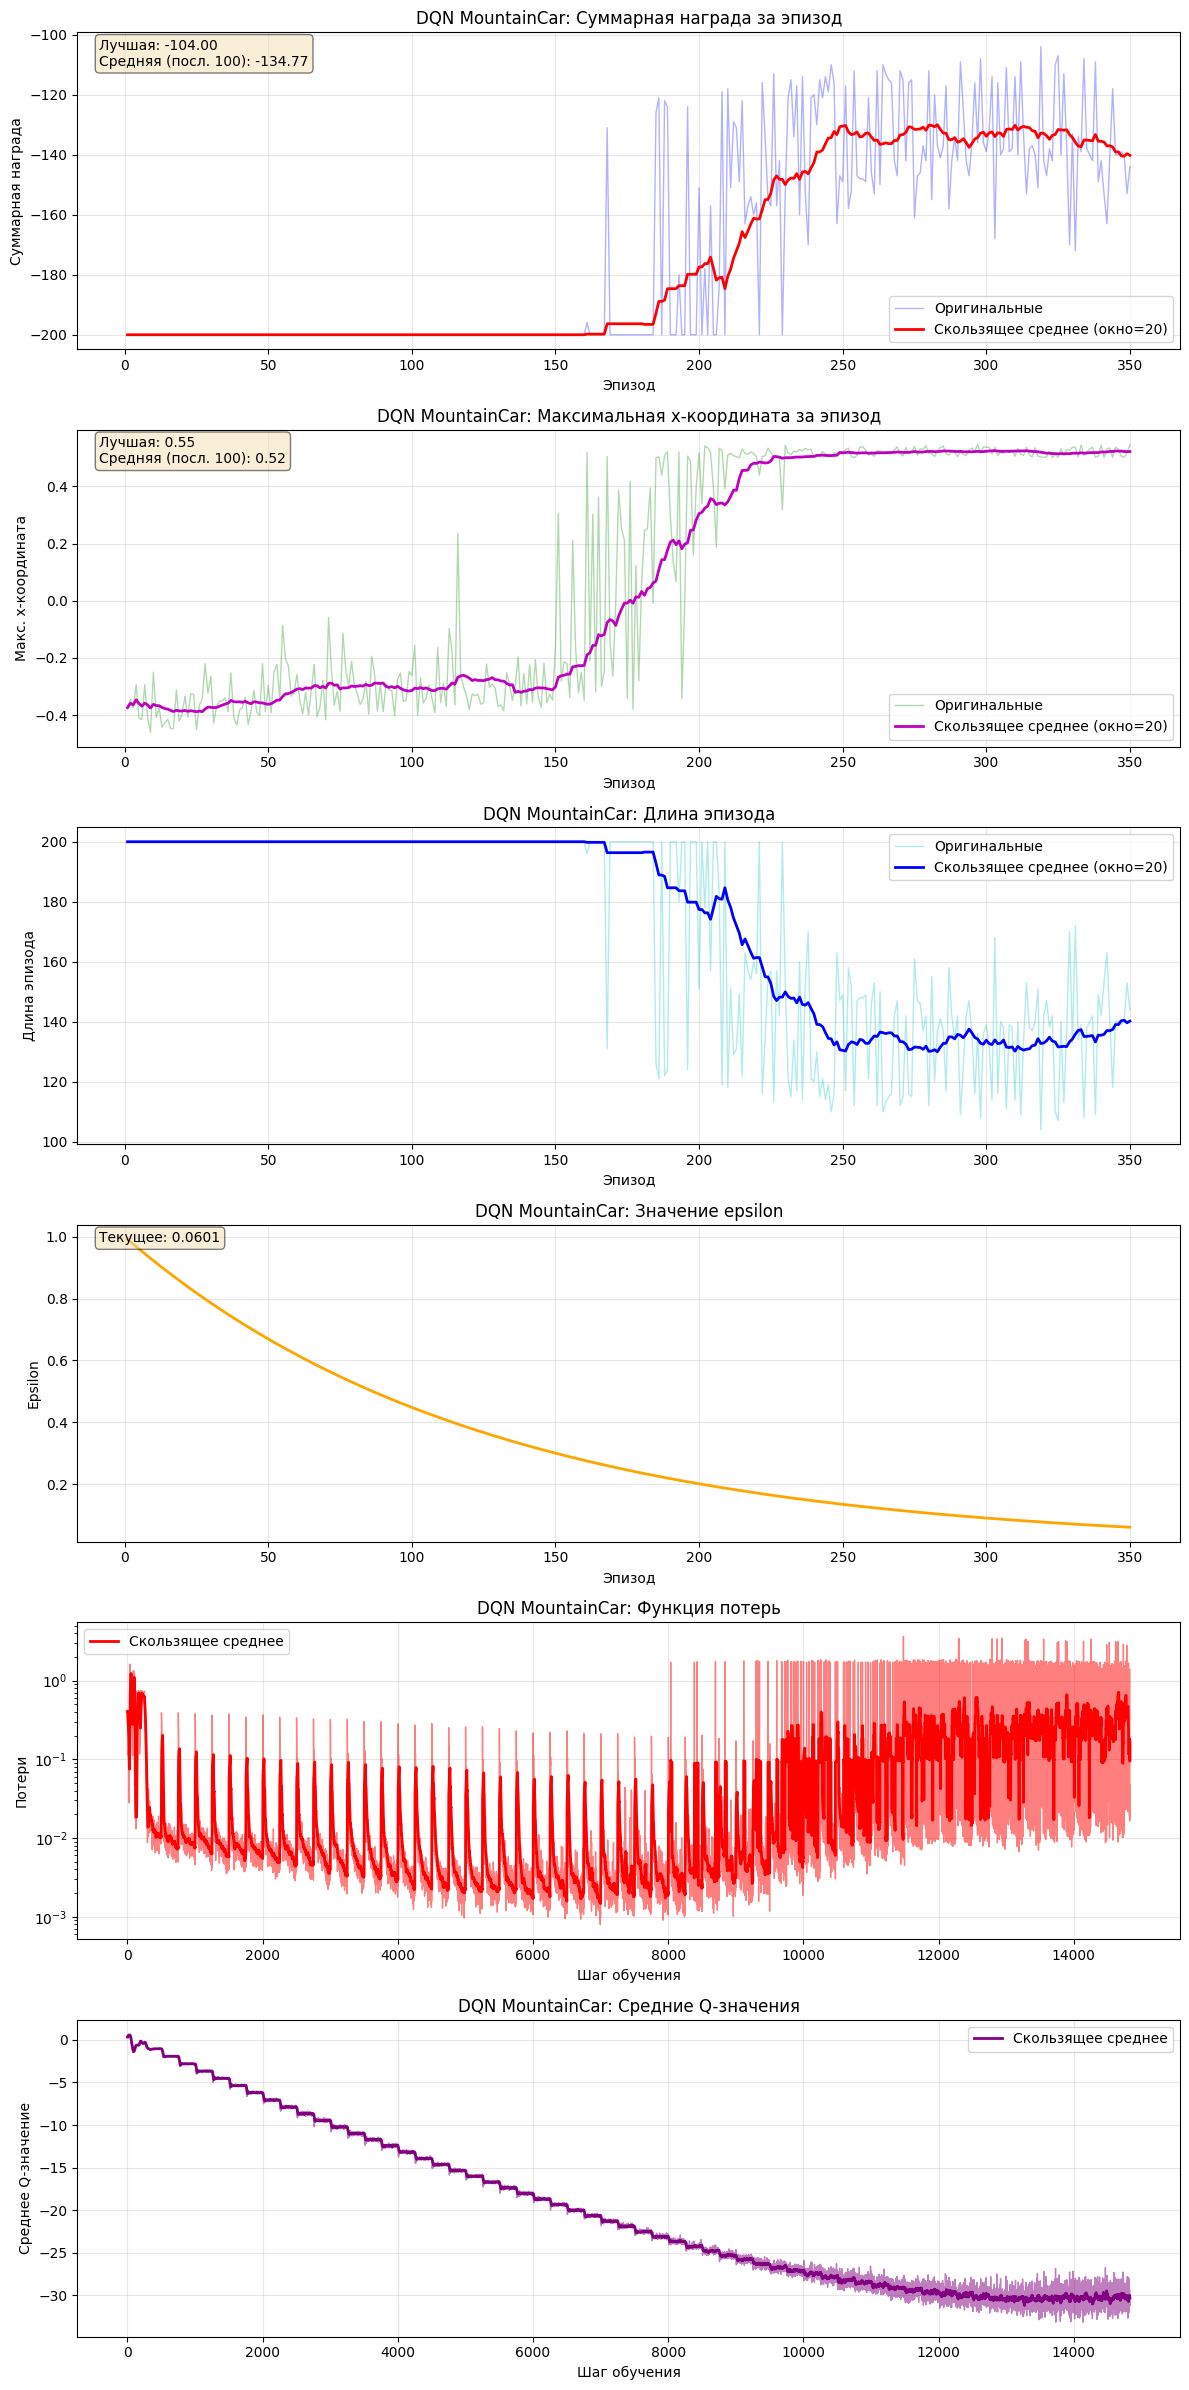

Эпизод  1: УСПЕХ   | reward=-113.0 | max_x=0.514
Эпизод  2: УСПЕХ   | reward=-118.0 | max_x=0.536
Эпизод  3: УСПЕХ   | reward=-113.0 | max_x=0.505
Эпизод  4: УСПЕХ   | reward=-113.0 | max_x=0.503
Эпизод  5: УСПЕХ   | reward=-115.0 | max_x=0.536
Эпизод  6: УСПЕХ   | reward=-114.0 | max_x=0.536
Эпизод  7: УСПЕХ   | reward=-114.0 | max_x=0.536
Эпизод  8: УСПЕХ   | reward= -88.0 | max_x=0.501
Эпизод  9: УСПЕХ   | reward=-114.0 | max_x=0.521
Эпизод 10: УСПЕХ   | reward=-114.0 | max_x=0.514

Результаты оценки:
  Успешных эпизодов: 10/10 (100.0%)
  Средняя награда: -111.60 ± 7.99
  Средний max x: 0.520; лучший max x: 0.536


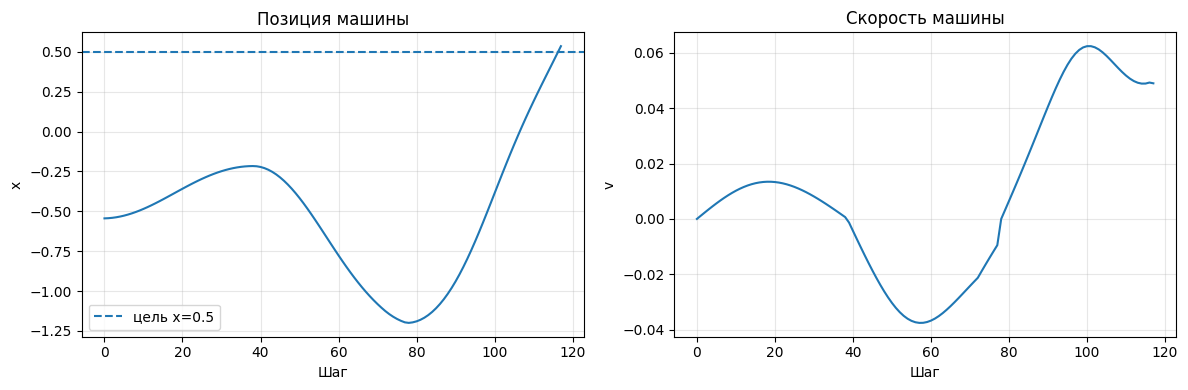

Демонстрация: reward=-117.0, max_x=0.536, успех=True


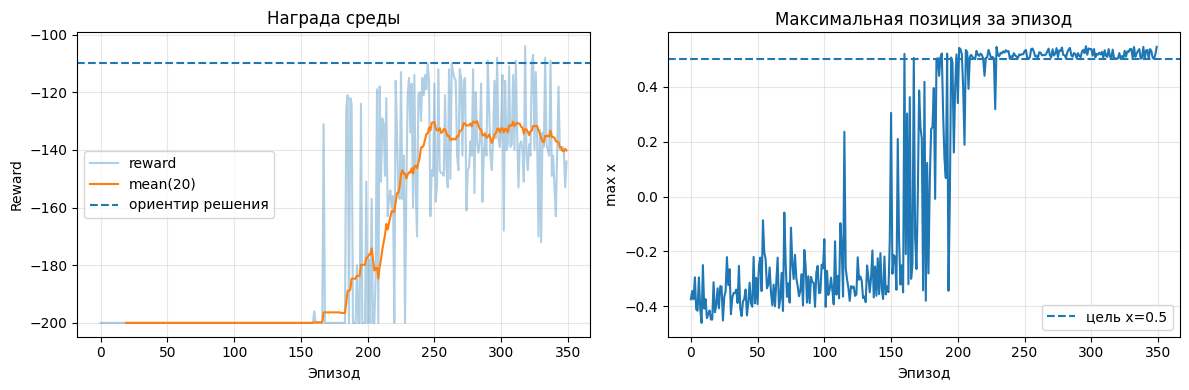

In [16]:
import os
import json
import numpy as np
import torch as th
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.wrappers import TransformObservation


TASK6_SAVE_DIR = 'mountaincar_dqn_results'
TASK6_WEIGHTS_PATH = os.path.join(TASK6_SAVE_DIR, 'best_policy_weights.pth')
TASK6_METADATA_PATH = os.path.join(TASK6_SAVE_DIR, 'best_policy_metadata.json')


def create_environment(render_mode=None):
    """Создаёт MountainCar-v0 и преобразует наблюдения в torch.float32."""
    kwargs = {} if render_mode is None else {'render_mode': render_mode}
    env = gym.make('MountainCar-v0', **kwargs)

    def transform_observation(observation):
        return th.as_tensor(observation, dtype=th.float32)

    try:
        # Gymnasium >= 1.0
        env = TransformObservation(
            env,
            transform_observation,
            observation_space=env.observation_space,
        )
    except TypeError:
        # Gymnasium 0.29.x
        env = TransformObservation(env, transform_observation)
    return env


def _save_weights_only(policy, path=TASK6_WEIGHTS_PATH, metadata=None):
    """Сохраняет только state_dict — такой файл безопасно читается с weights_only=True."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    state_dict = {
        name: tensor.detach().cpu()
        for name, tensor in policy.policy_network.state_dict().items()
    }
    th.save(state_dict, path)

    if metadata is not None:
        clean_metadata = {
            'observation_dim': int(metadata['observation_dim']),
            'action_dim': int(metadata['action_dim']),
            'hidden_dim': int(metadata['hidden_dim']),
        }
        with open(TASK6_METADATA_PATH, 'w', encoding='utf-8') as f:
            json.dump(clean_metadata, f, ensure_ascii=False, indent=2)
    return path


def _export_best_weights(trainer):
    """Экспортирует лучшую policy network в tensor-only checkpoint.

    Trainer сохраняет best_model.pth. После исправления размерностей на обычные int
    этот checkpoint читается weights_only=True. Если по какой-то причине он недоступен,
    используется тогда финальная policy из памяти — без небезопасного pickle fallback.
    """
    best_checkpoint_path = os.path.join(trainer.config.save_dir, 'best_model.pth')
    state_dict = None
    source = 'final policy from memory'

    if os.path.exists(best_checkpoint_path):
        try:
            checkpoint = th.load(
                best_checkpoint_path,
                map_location='cpu',
                weights_only=True,
            )
            candidate = checkpoint.get('policy_state_dict') if isinstance(checkpoint, dict) else None
            if isinstance(candidate, dict):
                state_dict = candidate
                source = 'best_model.pth'
        except Exception:
            # Безопасный fallback на текущую сеть; weights_only=False 
            state_dict = None

    if state_dict is None:
        state_dict = trainer.policy.policy_network.state_dict()

    os.makedirs(trainer.config.save_dir, exist_ok=True)
    tensor_only = {
        name: tensor.detach().cpu()
        for name, tensor in state_dict.items()
    }
    th.save(tensor_only, TASK6_WEIGHTS_PATH)

    metadata = {
        'observation_dim': int(trainer.policy.cfg.observation_dim),
        'action_dim': int(trainer.policy.cfg.action_dim),
        'hidden_dim': int(trainer.policy.cfg.hidden_dim),
        'source': source,
    }
    with open(TASK6_METADATA_PATH, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print(f"Безопасный checkpoint весов сохранён: {TASK6_WEIGHTS_PATH} (source: {source})")
    return TASK6_WEIGHTS_PATH


def train_mountaincar_dqn():
    """Обучает Double DQN. Метрики reward соответствуют исходной награде среды."""
    env = create_environment()
    os.makedirs(TASK6_SAVE_DIR, exist_ok=True)

    # Приведение размерности к Python int. Это важно для PyTorch 2.6+: np.int64 внутри checkpoint может мешать weights_only=True.
    observation_dim = int(env.observation_space.shape[0])
    action_dim = int(env.action_space.n)

    policy_config = PolicyConfig(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=64,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.992,
        use_double_dqn=True,
        seed=0,
    )
    train_config = TrainConfig(
        num_episodes=350,
        gamma=0.99,
        learning_rate=5e-4,
        batch_size=64,
        target_update_freq=1000,
        replay_memory_size=50000,
        min_memory_size=1000,
        max_steps_per_episode=200,
        grad_clip=5.0,
        train_freq=4,
        eval_freq=25,
        eval_episodes=5,
        print_freq=25,
        save_freq=100,
        save_dir=TASK6_SAVE_DIR,
        # В MountainCar-v0 исходный reward равен -1 за шаг.
        # Shaping используется только как обучающий сигнал; в метриках остаётся env reward.
        reward_shaping=True,
        velocity_reward_scale=15.0,
        goal_bonus=100.0,
        seed=0,
    )

    policy = Policy(policy_config)
    trainer = Trainer(env, train_config, policy)
    trainer.train()

    # Перекладывание лучшей модели в tensor-only checkpoint, который гарантированно совместим с torch.load(..., weights_only=True).
    _export_best_weights(trainer)

    plot_metrics(
        episode_rewards=trainer.episode_rewards,
        max_x_positions=trainer.max_x_positions,
        episode_lengths=trainer.episode_lengths,
        epsilon_values=trainer.epsilon_values,
        losses=trainer.losses,
        q_values=trainer.q_values,
        smoothing_window=20,
        save_path=os.path.join(train_config.save_dir, 'final_training_metrics.png'),
        title_prefix='DQN MountainCar: ',
        show_plots=True,
    )
    env.close()
    return trainer


def _load_trained_policy(weights_path=TASK6_WEIGHTS_PATH):
    """Загружает tensor-only checkpoint без pickle-объектов/NumPy scalar."""
    if not os.path.exists(weights_path):
        raise FileNotFoundError(
            f'Файл {weights_path} не найден. Сначала запустите train_mountaincar_dqn().'
        )

    env = create_environment()
    observation_dim = int(env.observation_space.shape[0])
    action_dim = int(env.action_space.n)
    hidden_dim = 64

    if os.path.exists(TASK6_METADATA_PATH):
        with open(TASK6_METADATA_PATH, 'r', encoding='utf-8') as f:
            metadata = json.load(f)
        observation_dim = int(metadata.get('observation_dim', observation_dim))
        action_dim = int(metadata.get('action_dim', action_dim))
        hidden_dim = int(metadata.get('hidden_dim', hidden_dim))

    cfg = PolicyConfig(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=hidden_dim,
        device='cuda' if th.cuda.is_available() else 'cpu',
        epsilon_start=0.0,
        epsilon_end=0.0,
        epsilon_decay=1.0,
        use_double_dqn=True,
        seed=0,
    )
    policy = Policy(cfg)

    try:
        state_dict = th.load(
            weights_path,
            map_location=policy.device,
            weights_only=True,
        )
    except TypeError:
        # PyTorch < 2.0/старые версии без аргумента weights_only.
        # Файл содержит только state_dict, созданный этой ячейкой.
        state_dict = th.load(weights_path, map_location=policy.device)

    if not isinstance(state_dict, dict):
        env.close()
        raise ValueError('Некорректный файл весов: ожидался state_dict')

    policy.policy_network.load_state_dict(state_dict)
    policy.sync_models()
    policy.eval()
    return env, policy, weights_path


def evaluate_trained_model(episodes=10, weights_path=TASK6_WEIGHTS_PATH):
    """Оценивает жадную политику на исходной награде MountainCar-v0."""
    env, policy, model_path = _load_trained_policy(weights_path)
    rewards, max_positions = [], []
    successes = 0

    try:
        for episode in range(int(episodes)):
            state, _ = env.reset(seed=500000 + episode)
            total_reward = 0.0
            max_x = float(state[0].item())
            terminated = False

            for _ in range(200):
                action = policy.get_best_action(state)
                state, reward, terminated, truncated, _ = env.step(action)
                total_reward += float(reward)
                max_x = max(max_x, float(state[0].item()))
                if terminated or truncated:
                    break

            rewards.append(total_reward)
            max_positions.append(max_x)
            successes += int(bool(terminated))
            status = 'УСПЕХ' if terminated else 'неудача'
            print(
                f"Эпизод {episode + 1:2d}: {status:7s} | "
                f"reward={total_reward:6.1f} | max_x={max_x:.3f}"
            )
    finally:
        env.close()

    success_rate = successes / int(episodes)
    result = {
        'model_path': model_path,
        'episodes': int(episodes),
        'successes': int(successes),
        'success_rate': float(success_rate),
        'mean_reward': float(np.mean(rewards)),
        'std_reward': float(np.std(rewards)),
        'mean_max_x': float(np.mean(max_positions)),
        'best_max_x': float(np.max(max_positions)),
    }
    print('\nРезультаты оценки:')
    print(f"  Успешных эпизодов: {successes}/{episodes} ({100 * success_rate:.1f}%)")
    print(f"  Средняя награда: {result['mean_reward']:.2f} ± {result['std_reward']:.2f}")
    print(
        f"  Средний max x: {result['mean_max_x']:.3f}; "
        f"лучший max x: {result['best_max_x']:.3f}"
    )
    return result


def run_demo_episode(weights_path=TASK6_WEIGHTS_PATH):
    """Запускает один greedy-эпизод и визуализирует траекторию."""
    env, policy, _ = _load_trained_policy(weights_path)
    state, _ = env.reset(seed=600000)
    positions = [float(state[0].item())]
    velocities = [float(state[1].item())]
    total_reward = 0.0
    terminated = False

    try:
        for _ in range(200):
            action = policy.get_best_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            positions.append(float(state[0].item()))
            velocities.append(float(state[1].item()))
            total_reward += float(reward)
            if terminated or truncated:
                break
    finally:
        env.close()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(positions)
    axes[0].axhline(0.5, linestyle='--', label='цель x=0.5')
    axes[0].set_title('Позиция машины')
    axes[0].set_xlabel('Шаг')
    axes[0].set_ylabel('x')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(velocities)
    axes[1].set_title('Скорость машины')
    axes[1].set_xlabel('Шаг')
    axes[1].set_ylabel('v')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"Демонстрация: reward={total_reward:.1f}, "
        f"max_x={max(positions):.3f}, успех={bool(terminated)}"
    )
    return bool(terminated), float(total_reward), float(max(positions))


def plot_detailed_analysis():
    """Строит дополнительный анализ по сохранённой истории обучения."""
    history_path = os.path.join(TASK6_SAVE_DIR, 'training_history.json')
    if not os.path.exists(history_path):
        raise FileNotFoundError(
            'История обучения не найдена; сначала запустите train_mountaincar_dqn()'
        )

    with open(history_path, 'r', encoding='utf-8') as f:
        history = json.load(f)

    rewards = np.asarray(history['episode_rewards'], dtype=float)
    max_x = np.asarray(history['max_x_positions'], dtype=float)
    if rewards.size == 0:
        raise ValueError('История обучения пуста')

    window = min(20, len(rewards))
    kernel = np.ones(window, dtype=float) / window
    reward_ma = np.convolve(rewards, kernel, mode='valid')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(rewards, alpha=0.35, label='reward')
    axes[0].plot(
        np.arange(window - 1, len(rewards)),
        reward_ma,
        label=f'mean({window})',
    )
    axes[0].axhline(-110, linestyle='--', label='ориентир решения')
    axes[0].set_title('Награда среды')
    axes[0].set_xlabel('Эпизод')
    axes[0].set_ylabel('Reward')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(max_x)
    axes[1].axhline(0.5, linestyle='--', label='цель x=0.5')
    axes[1].set_title('Максимальная позиция за эпизод')
    axes[1].set_xlabel('Эпизод')
    axes[1].set_ylabel('max x')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Основной запуск: обучение -> безопасное сохранение весов -> проверка загрузки -> анализ.
trainer = train_mountaincar_dqn()
evaluation = evaluate_trained_model(episodes=10)
demo_result = run_demo_episode()
plot_detailed_analysis()


### В начале обучения агент не достигает целевого положения, поэтому эпизоды завершаются по ограничению в 200 шагов и имеют награду −200. Примерно после 170–200 эпизодов политика начинает успешно достигать позиции x ≥ 0.5. По мере обучения среднее число шагов до достижения цели уменьшается, что отражается в росте суммарной награды от −200 примерно до −130 и отдельных значений около −107

## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ